In [3]:
%pip install --upgrade pip

# Uninstall conflicting packages
%pip uninstall -y langchain-core langchain-openai langchain-experimental langchain-community langchain chromadb beautifulsoup4 python-dotenv PyPDF2 rank_bm25 tiktoken langgraph

# Install compatible versions of langchain libraries
%pip install langchain-core==0.3.6
%pip install langchain-openai==0.2.1
%pip install langchain-experimental==0.3.2
%pip install langchain-community==0.3.1
%pip install langchain==0.3.1

# Install remaining packages
%pip install chromadb==0.5.11
%pip install beautifulsoup4==4.12.3
%pip install python-dotenv==1.0.1
%pip install PyPDF2==3.0.1 -q --user
%pip install rank_bm25==0.2.2

# new agent-related installs
%pip install tiktoken==0.7.0
%pip install langgraph==0.2.28

# Restart the kernel after installation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Found existing installation: langchain-core 0.3.68
Uninstalling langchain-core-0.3.68:
  Successfully uninstalled langchain-core-0.3.68
Found existing installation: langchain 0.3.26
Uninstalling langchain-0.3.26:
  Successfully uninstalled langchain-0.3.26
Found existing installation: beautifulsoup4 4.13.4
Uninstalling beautifulsoup4-4.13.4:
  Successfully uninstalled beautifulsoup4-4.13.4
Found existing installation: tiktoken 0.9.0
Uninstalling tiktoken-0.9.0:
  Successfully uninstalled tiktoken-0.9.0
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.4.5
    Uninstalling langsmith-0.4.5:
      Successfully uninstalled langsmith-0.4.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langchain-core]
ERROR: pip's dependency resolver does not c

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.4 MB/s eta 0:00:00
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.25
    Uninstalling langchain-0.3.25:
      Successfully uninstalled langchain-0.3.25
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.0/604.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 101.7 MB/s eta 0:00:00
  Created wheel for pypika: filename=pypika-0.48.9-py2.py3-none-any.whl size=53803 sha256=18921cc3d7b89c46343eb63a17936869757517ac44b003e2a4b692ff0863b27d
  Stored in directory: /root/.cache/pip/wheels/a3/01/bd/4c40ceb9d5354160c

In [1]:
import os
os.environ['USER_AGENT'] = 'RAGUserAgent'
import openai
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import chromadb
from langchain_community.vectorstores import Chroma
from langchain_core.runnables import RunnableParallel
from dotenv import load_dotenv, find_dotenv
from langchain_core.prompts import PromptTemplate
from PyPDF2 import PdfReader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.docstore.document import Document
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever

In [2]:
# variables
# OpenAI Setup
!pip install google.colab
from google.colab import userdata
os.environ["OPENAI_API_VERSION"] = "2024-08-01-preview"
os.environ['AZURE_OPENAI_API_KEY'] = userdata.get('AZURE_OPENAI_API_KEY')
os.environ["AZURE_OPENAI_ENDPOINT"] = userdata.get('AZURE_OPENAI_ENDPOINT')
os.environ["AZURE_OPENAI_EMBEDDING_ENDPOINT"] = userdata.get('AOAI_EMBEDDING_ENDPOINT')
embedding_function = AzureOpenAIEmbeddings(model="text-embedding-ada-002", azure_endpoint=userdata.get('AOAI_EMBEDDING_ENDPOINT'), api_key=userdata.get('AOAI_EMBEDDING_KEY'))
llm = AzureChatOpenAI(model_name="gpt-4o-mini")
agent_llm = AzureChatOpenAI(model_name="gpt-4o-mini", temperature=0, streaming=True)

# variables
pdf_path = "sample_data/google-2023-environmental-report.pdf"
collection_name = "google_environmental_report"
str_output_parser = StrOutputParser()
user_query = "What are Google's environmental initiatives?"



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.3 MB/s eta 0:00:00


In [3]:
#### INDEXING ####

In [4]:
# Load the PDF and extract text
pdf_reader = PdfReader(pdf_path)
text = ""
for page in pdf_reader.pages:
    text += page.extract_text()

In [5]:
# Split
character_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=1000,
    chunk_overlap=200
)
splits = character_splitter.split_text(text)

In [6]:
dense_documents = [Document(page_content=text, metadata={"id": str(i), "source": "dense"}) for i, text in enumerate(splits)]
sparse_documents = [Document(page_content=text, metadata={"id": str(i), "source": "sparse"}) for i, text in enumerate(splits)]

In [7]:
# Chroma Vector Store
chroma_client = chromadb.Client()
vectorstore = Chroma.from_documents(
    documents=dense_documents,
    embedding=embedding_function,
    collection_name=collection_name,
    client=chroma_client
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [8]:
dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})
sparse_retriever = BM25Retriever.from_documents(sparse_documents, k=10)
ensemble_retriever = EnsembleRetriever(retrievers=[dense_retriever, sparse_retriever], weights=[0.5, 0.5], c=0)

In [9]:
#### TOOLS ####

In [10]:
# Tool #1: Web Search

In [11]:
# Tavily Setup
# set up your API key at https://tavily.com/
# add the API key to your env.txt file
from langchain_community.tools.tavily_search import TavilySearchResults

os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')
!export TAVILY_API_KEY=os.environ['TAVILY_API_KEY']
web_search = TavilySearchResults(max_results=4)
web_search_name = web_search.name

In [12]:
web_search.invoke(user_query)

[{'url': 'https://sustainability.google/operations/',
  'content': '2025 Environmental Report\n   2025 European Union NFRD Report\n   Alphabet’s 2023 CDP Climate Change Response\n   2024 Statement Against Modern Slavery\n   2023 Supplier Responsibility Report\n   View all\n\n### Other Google initiatives\n\n   Accessibility\n   Crisis response\n   Digital wellbeing\n   Belonging\n   Safety Center\n   Google for Health\n   Grow with Google\n\n  \n\n\n\n   About Google\n   Google products\n   Privacy\n   Terms\n\n   Help [...] We’re also accelerating the circular economy by designing out waste and increasing material reuse in our data centers. We’re integrating sustainability into our consumer hardware, focusing on product longevity through software updates and repair options, and striving for a more sustainable supply chain. [...] Overview\n\n### Other Google initiatives\n\n   Accessibility\n   Crisis response\n   Digital wellbeing\n   Belonging\n   Safety Center\n   Google for Health\n 

In [13]:
# Tool #2: Data Retriever

In [14]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    ensemble_retriever,
    "retrieve_google_environmental_question_answers",
    "Extensive information about Google environmental efforts from 2023.",
)
retriever_tool_name = retriever_tool.name

In [15]:
# Define tools for agent
tools = [web_search, retriever_tool]

In [16]:
from typing import Annotated, Literal, Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [17]:
from langchain_core.messages import HumanMessage
from langchain_core.pydantic_v1 import BaseModel, Field
from langgraph.prebuilt import tools_condition

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


In [18]:
generation_prompt = PromptTemplate.from_template(
    """You are an assistant for question-answering tasks.
    Use the following pieces of retrieved context to answer
    the question. If you don't know the answer, just say
    that you don't know. Provide a thorough description to
    fully answer the question, utilizing any relevant
    information you find.

    Question: {question}
    Context: {context}

    Answer:"""
)

In [19]:
### Edges - determines whether the retrieved documents are relevant to the question.
def score_documents(state) -> Literal["generate", "improve"]:

    print("---CHECK RELEVANCE---")

    # Data model - returns a binary score for the relevance check
    class scoring(BaseModel):
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM with tool and validation
    llm_with_tool = llm.with_structured_output(scoring)

    # Prompt
    prompt = PromptTemplate(
        template="""
        You are assessing relevance of a retrieved document to a user question with a binary grade. \n

        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n

        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
        """,
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]
    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})
    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "improve"

In [20]:
### Nodes

In [21]:
# Agent node - invokes the agent model to generate a response based on the current state.
# Decision choices (given the question): retrieve using the retriever tool, web_search tool, both, or end.
def agent(state):
    print("---CALL AGENT---")
    messages = state["messages"]
    llm = agent_llm.bind_tools(tools)
    response = llm.invoke(messages)
    return {"messages": [response]} # Return list, will get added to existing list

In [22]:
# Improve node - transform the query to produce a better question.
def improve(state):
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(content=f"""\n
            Look at the input and try to reason about the underlying semantic intent / meaning. \n
            Here is the initial question:
            \n ------- \n
            {question}
            \n ------- \n
            Formulate an improved question:
            """,
        )
    ]

    # Scoring
    response = llm.invoke(msg)
    return {"messages": [response]}

In [23]:
# Generate node - generate answer
def generate(state):
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    # Chain
    rag_chain = generation_prompt | llm | str_output_parser

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [24]:
# Cyclical Graph Setup
from langgraph.graph import END, StateGraph
from langgraph.prebuilt import ToolNode

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode(tools)
workflow.add_node("retrieve", retrieve)  # retrieval from web and or retriever
workflow.add_node("improve", improve)  # Improving the question for better retrieval
workflow.add_node("generate", generate)  # Generating a response after we know the documents are relevant

# Call agent node to decide to retrieve or not
workflow.set_entry_point("agent")

# Decide whether to retrieve (assess agent decision)
workflow.add_conditional_edges("agent", tools_condition,
    # Translate the condition outputs to nodes in our graph
    {
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called (assess agent decision)
workflow.add_conditional_edges("retrieve", score_documents)
workflow.add_edge("generate", END)
workflow.add_edge("improve", "agent")

# Compile
graph = workflow.compile()

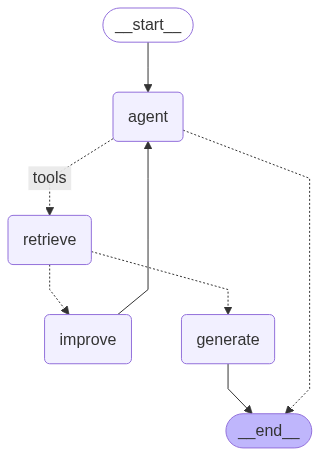

In [25]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except:
    pass

In [26]:
import pprint

inputs = {
    "messages": [
        ("user", user_query),
    ]
}
final_answer = ''
for output in graph.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"Output from node '{key}':")
        pprint.pprint("---")
        pprint.pprint(value, indent=2, width=80, depth=None)
        final_answer = value
    pprint.pprint("\n---\n")

---CALL AGENT---
"Output from node 'agent':"
'---'
{ 'messages': [ AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_XdZEz08C3uFsdVWOrZ19sS1y', 'function': {'arguments': '{"query":"Google environmental initiatives"}', 'name': 'retrieve_google_environmental_question_answers'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': 'fp_0165350fbb'}, id='run--aa896d97-fac0-4fb4-9cb2-7d2dbe549d44-0', tool_calls=[{'name': 'retrieve_google_environmental_question_answers', 'args': {'query': 'Google environmental initiatives'}, 'id': 'call_XdZEz08C3uFsdVWOrZ19sS1y', 'type': 'tool_call'}])]}
'\n---\n'


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
"Output from node 'retrieve':"
'---'
{ 'messages': [ ToolMessage(content='Protection Agency (EPA), including 3 Google hosted events with EPA Administrator Michael \nRegan on environmental justice, how Google products promote recycling within the circular \neconomy, and using AI to identify lead pipes. At the U.S. Department of Energy, Nest continued \ndialog with both the Loans Program Office about designation as an innovative product, and \nOffice of the Under Secretary for Science and Innovation. We also met with the White House  \non multiple projects, and received invitations to summits for our work on lead pipe reduction \nand home electrification.U.S. SEC comments \non proposed rule on \nEnhancement and \nStandardization of \nClimate-Related \nDisclosures for \nInvestorsIn partnership with nine other peer technology companies, Google provided comments  to \nthe Securities and Exchange Commission’s (SEC) proposed rule on enhanced

In [27]:
final_answer['messages'][0]

"Google has several environmental initiatives in place to promote sustainability and reduce its carbon footprint. One of the key initiatives is empowering individuals to take action through their products, such as eco-friendly routing in Google Maps, energy efficiency features in Google Nest thermostats, and carbon emissions information in Google Flights. Google also works with partners and customers to collectively reduce 1 gigaton of carbon equivalent emissions annually by 2030. \n\nIn terms of partnerships and advocacy, Google is a strategic partner of the RE-Source Platform, which focuses on corporate renewable energy sourcing in Europe. Google also engages with coalitions like the iMasons Climate Accord and supports initiatives like the European Climate Pact and the European Green Digital Coalition. They have joined the Climate Neutral Data Centre Pact and are a partner of the Ellen MacArthur Foundation, focusing on areas like safer chemistry and circular economy practices.\n\nGoo

*Formatted:*

Google has a comprehensive and multifaceted approach to environmental sustainability, encompassing various initiatives aimed at reducing carbon emissions, promoting sustainable practices, and leveraging technology for environmental benefits. Here are some key aspects of Google's environmental initiatives:

1. **Carbon Reduction and Renewable Energy**:  
- **iMasons Climate Accord**: Google is a founding member and part of the governing body of this coalition focused on reducing carbon emissions in digital infrastructure.
- **Net-Zero Carbon**: Google is committed to operating sustainably with a focus on achieving net-zero carbon emissions. This includes investments in carbon-free energy and energy-efficient facilities, such as their all-electric, net water-positive Bay View campus.

2. **Sustainable Consumption and Circular Economy**:
- **Right to Repair**: Google has engaged with the European Commission to promote the repair and reuse of goods, particularly smartphones and tablets.
- **Circular Economy**: Google works with suppliers to ensure environmental criteria are met, including the management of hazardous substances and resource efficiency. They also promote recycling and the use of refurbished products.

3. **Water Stewardship**:
- Google supports watershed projects and responsible water use, including initiatives in Chile and the United States. Their Bay View campus incorporates stormwater retention and other water-positive features.

4. **Food Waste Reduction**:
- **ReFED**: Google provided anchor funding to the ReFED Catalytic Grant Fund to accelerate and scale food waste solutions.

5. **Reforestation and Biodiversity**:
- **The Nature Conservancy (TNC)**: Google supports reforestation projects and the development of technology to stop deforestation in the Amazon. They also work on kelp reforestation and other biodiversity initiatives.

6. **Technology and Data for Environmental Action**:
- **Google Earth Engine**: Provides access to data for monitoring environmental changes.
- **Environmental Insights Explorer**: Helps cities and organizations measure and reduce their carbon footprint.
- **Google Maps Eco-Friendly Routing**: Offers routes that reduce carbon emissions, helping users make more sustainable travel choices.

7. **Public Policy and Advocacy**:
- Google engages in public policy advocacy to support clean energy and climate action, including comments on the U.S. Department of Energy's Clean Hydrogen Production Standard and participation in the First Movers Coalition for carbon dioxide removal.

8. **Partnerships and Coalitions**:
- Google collaborates with various organizations, including the World Business Council for Sustainable Development (WBCSD) and the World Resources Institute (WRI), to promote sustainability and address climate change.

9. **Empowering Individuals and Communities**:
- Google aims to help 1 billion people make more sustainable choices through their products by 2030. This includes features like energy-efficient Google Nest thermostats and carbon emissions information in Google Flights.

Overall, Google's environmental initiatives are extensive and integrated into their business operations, product development, and community engagement, reflecting their commitment to sustainability and climate action.